# # ERT Data Inversion & Visualization using pyGIMLi
Performs conventional Electrical Resistivity Tomography (ERT) inversion on processed 
*_rhoa.txt` data files directly in the base directory and exports inversion tomograms.

In [1]:
# %% Imports and Environment Setup
import importlib
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pygimli as pg
from pygimli.physics import ert
from pathlib import Path

# Close any pre-existing plots
plt.close("all")

In [2]:
# Target profile (matches the filename prefix without extension)
profile = "BUL01_2023-08-05_W3m"

In [3]:
# 1. Dynamically locate the repository root (works regardless of cell re-runs or cwd)
current_path = Path.cwd().resolve()
repo_root = None

for parent in [current_path] + list(current_path.parents):
    if (parent / ".git").exists() or parent.name == "central-asia-permafrost-geophysics":
        repo_root = parent
        break

if repo_root is None:
    raise FileNotFoundError("Could not locate repository root directory!")

# 2. Build paths from the repository root
base_path = repo_root / "data" / "geophysics" / "raw" / "001_ERT" / "003_udf"
figures_dir = repo_root / "figures"
path_settings = repo_root / "scripts" / "field_case"

# Ensure output directories exist
figures_dir.mkdir(parents=True, exist_ok=True)

# 3. Change active working directory to data path for pyGIMLi
os.chdir(base_path)

# Extract simple profile title
profile_title = profile.split("_")[0]

print(f"✓ Repo Root:           {repo_root}")
print(f"✓ Working Data Dir:    {os.getcwd()}")
print(f"✓ Figures Dir:         {figures_dir}")
print(f"✓ Target Profile:      {profile}")

✓ Repo Root:           C:\Users\mathyst\OneDrive - Université de Fribourg\projects\central-asia-permafrost-geophysics
✓ Working Data Dir:    C:\Users\mathyst\OneDrive - Université de Fribourg\projects\central-asia-permafrost-geophysics\data\geophysics\raw\001_ERT\003_udf
✓ Figures Dir:         C:\Users\mathyst\OneDrive - Université de Fribourg\projects\central-asia-permafrost-geophysics\figures
✓ Target Profile:      BUL01_2023-08-05_W3m


In [4]:
# %% Load Settings (Lambda, Weights, Color Scale Limits)
# Set default inversion parameters in case settings file is missing
lame = 10  # Regularization parameter (lam)
zWeighte = 1.0  # Vertical anisotropy weight
maxItere = 20  # Max inversion iterations
cMine = 10  # Min resistivity for colorbar
ylimmin = None  # Lower y-axis limit for plot

settings_file_1 = os.path.join(path_settings, f"settings_{profile}.py")
settings_file_2 = os.path.join(base_path, f"settings_{profile}.py")

if os.path.exists(settings_file_1):
    print(f"Loading settings from: {settings_file_1}")
    sys.path.append(path_settings)
    settings_module = importlib.import_module(f"settings_{profile}")
    globals().update(vars(settings_module))
elif os.path.exists(settings_file_2):
    print(f"Loading settings from: {settings_file_2}")
    sys.path.append(base_path)
    settings_module = importlib.import_module(f"settings_{profile}")
    globals().update(vars(settings_module))
else:
    print("No profile settings file found. Using default parameters.")

No profile settings file found. Using default parameters.


In [5]:
# %% Load Data Files via Relative Filenames
file_rhoa = f"{profile}_rhoa.txt"
file_topo = f"{profile}_topo.txt"

# Check for double extension (.txt.txt) if standard file is missing
if not os.path.exists(file_rhoa) and os.path.exists(file_rhoa + ".txt"):
    file_rhoa += ".txt"

if not os.path.exists(file_rhoa):
    raise FileNotFoundError(
        f"Could not find ERT file '{file_rhoa}' in {os.getcwd()}"
    )

# Pass RELATIVE filename directly to pyGIMLi to avoid C++ special character errors
ertData = pg.DataContainerERT(file_rhoa)

# Create geometric factors
ertData["k"] = ert.createGeometricFactors(ertData, numerical=True)

print("--- ERT Data Summary ---")
print(ertData)

# Load topography if present
if os.path.exists(file_topo):
    topo = np.loadtxt(file_topo)
    spacing = topo[1][0] - topo[0][0] if len(topo) > 1 else 5.0
    print(
        f"✓ Loaded topography ({file_topo}): {len(topo)} points, spacing ~ {spacing:.2f} m"
    )
else:
    spacing = 5.0
    print(
        f"! Topography file '{file_topo}' not found. Proceeding with flat ground."
    )

20/07/26 - 15:13:01 - pyGIMLi - INFO - Create default mesh for geometric factor calculation.
20/07/26 - 15:13:03 - pyGIMLi - INFO - Save RVector binary
20/07/26 - 15:13:03 - pyGIMLi - INFO - Cache stored: C:\Users\mathyst\AppData\Roaming\pygimli\Cache\9874623645277254442


--- ERT Data Summary ---
Data: Sensors: 48 data: 360, nonzero entries: ['a', 'b', 'err', 'k', 'm', 'n', 'rhoa', 'valid']
✓ Loaded topography (BUL01_2023-08-05_W3m_topo.txt): 48 points, spacing ~ 2.00 m


In [6]:
# %% Execute ERT Inversion
mgr = ert.ERTManager(sr=False)
mgr.inv.inv.setBlockyModel(True)

print("\n--- Starting ERT Inversion ---")
resinv = mgr.invert(
    ertData,
    lam=lame,
    zWeight=zWeighte,
    maxIter=maxItere,
    quality=33.6,
    verbose=1,
)

chi2 = mgr.inv.chi2()
rms = mgr.inv.relrms()

print("\n--- Inversion Results ---")
print(f"Chi²:      {chi2:.2f}")
print(f"RMS Error: {rms:.2f}%")

20/07/26 - 15:13:03 - pyGIMLi - INFO - Found 2 regions.
20/07/26 - 15:13:03 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
20/07/26 - 15:13:03 - pyGIMLi - INFO - Found 2 regions.
20/07/26 - 15:13:03 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
20/07/26 - 15:13:03 - pyGIMLi - INFO - Creating forward mesh from region infos.
20/07/26 - 15:13:03 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
20/07/26 - 15:13:03 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 2628 Cells: 4980 Boundaries: 3872
20/07/26 - 15:13:03 - pyGIMLi - INFO - Use median(data values)=843.935



--- Starting ERT Inversion ---


20/07/26 - 15:13:03 - pyGIMLi - INFO - Created startmodel from forward operator:891, min/max=843.935000/843.935000
20/07/26 - 15:13:03 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x0000022DFED9CAE0>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 119/2970
min/max (error): 4%/4%
min/max (start model): 844/844
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  377.29
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =   33.89 (dPhi = 90.45%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =   23.93 (dPhi = 28.93%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =   16.97 (dPhi = 28.17%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =    8.23 (dPhi = 48.37%) lam: 10.0
--------------------------------------------------------

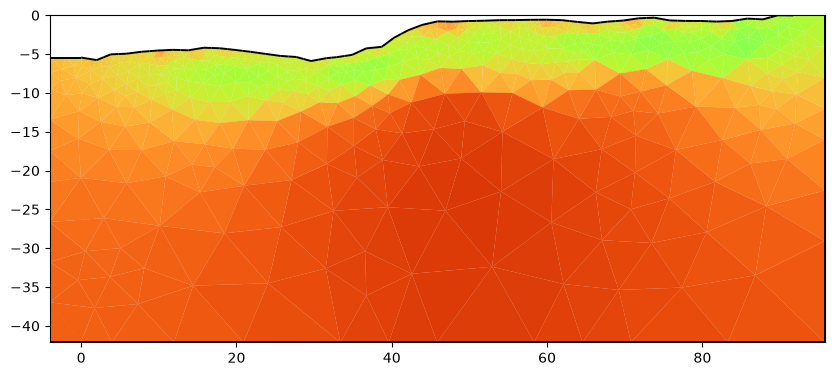

c:\Users\mathyst\AppData\Local\anaconda3\envs\pg_new\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1000x500 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


✓ Saved inverted resistivity -> BUL01_2023-08-05_W3m_res_conventional.dat
✓ Saved tomogram image        -> C:\Users\mathyst\OneDrive - Université de Fribourg\projects\central-asia-permafrost-geophysics\figures\BUL01_2023-08-05_W3m_ert.png


<Figure size 640x480 with 0 Axes>

In [7]:
# %% Cell 7: Plot and Save Tomogram
fig, ax = plt.subplots(figsize=(10, 5))

# Plot inverted resistivity distribution
ax, cBar = mgr.showResult(
    resinv,
    ax=ax,
    cMap="turbo_r",
    cMin=cMine if "cMine" in locals() else 10,
    cMax=1_000_000,
)

# Axis & Colorbar Formatting
cBar.set_label(r"$\rho$ [$\Omega$m]", fontsize=12)
cBar.ax.tick_params(labelsize=12)
ax.set_xlabel("Distance (m)", fontsize=12)
ax.set_ylabel("Depth (m)", fontsize=12)
ax.tick_params(axis="both", labelsize=12)

# Profile name as main title at the top
ax.set_title(profile, fontsize=14, fontweight="bold", pad=12)

# Clean up top/right borders
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

if "ylimmin" in locals() and ylimmin is not None:
    ax.set_ylim(bottom=ylimmin)

# Extract Chi2 and RMS values
chi2_val = mgr.inv.chi2()
rms_val = mgr.inv.relrms()

# Format LaTeX text in lower-left corner
tex_error_text = r"$\chi^2$ = %.2f, RMS error = %.2f%%" % (chi2_val, rms_val)

ax.text(
    0.03,
    0.05,
    tex_error_text,
    fontsize=12,
    transform=ax.transAxes,
    va="bottom",
    ha="left",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8, edgecolor="none"),
)

# Save output files
res_output = f"{profile}_res_conventional.dat"
fig_output = os.path.join(figures_dir, f"{profile}_ert.png")

np.savetxt(res_output, resinv)
fig.savefig(fig_output, bbox_inches="tight", dpi=300)

print(f"✓ Saved inverted resistivity -> {res_output}")
print(f"✓ Saved tomogram image        -> {fig_output}")

plt.show()